# NB18: Embedding Cluster Analysis

Analisis mendalam tentang **apa yang di-cluster oleh MT model** pada representasi  (ASD output dari cross-attention).

Bandingkan dengan ST model () untuk menjawab: *informasi apa yang dikumpulkan oleh hierarki MTL?*

In [1]:
import json
import os
import string
import gc

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from transformers import AutoModel, AutoTokenizer
from torchcrf import CRF
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_distances
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# Paths & Config
BASE_DIR = os.path.dirname(os.getcwd())
DATA_RAW_DIR = os.path.join(BASE_DIR, 'data', 'raw')
DATA_PROC_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODEL_DIR = os.path.join(BASE_DIR, 'models')

MODEL_NAME = 'indobenchmark/indobert-large-p2'
MAX_LENGTH = 128
PROJ_DIM = 256
DROPOUT = 0.1
MAX_REL_POS = 20
LAMBDA1 = 0.3
LAMBDA2 = 0.3
IGNORE_INDEX = -100
SEED = 42

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

# Labels
ate_labels   = ['O', 'B', 'I', 'E', 'S']
sld_labels   = ['O', 'POS', 'NEG']
asd_labels   = ['O', 'POS', 'NEG', 'NEU']
bieos_labels = ['O', 'B-NEG', 'B-NEU', 'B-POS', 'E-NEG', 'E-NEU', 'E-POS',
                'I-NEG', 'I-NEU', 'I-POS', 'S-NEG', 'S-NEU', 'S-POS']

ate_label2id   = {l: i for i, l in enumerate(ate_labels)}
sld_label2id   = {l: i for i, l in enumerate(sld_labels)}
asd_label2id   = {l: i for i, l in enumerate(asd_labels)}
bieos_label2id = {l: i for i, l in enumerate(bieos_labels)}
bieos_id2label = {i: l for l, i in bieos_label2id.items()}

print('Config loaded.')

Config loaded.


In [3]:
class CrossAttentionASD(nn.Module):
    def __init__(self, dim, max_relative_position=20):
        super().__init__()
        self.max_rel_pos = max_relative_position
        self.pos_embedding = nn.Embedding(2 * max_relative_position + 1, dim)
        self.W_ae = nn.Linear(dim, dim, bias=False)
        self.W_sl = nn.Linear(dim, dim, bias=False)
        self.W_pos = nn.Linear(dim, dim, bias=False)
        self.bias = nn.Parameter(torch.zeros(dim))
        self.w_s = nn.Linear(dim, 1, bias=False)
        self.last_attn_weights = None

    def forward(self, h_ae, h_sl, mask=None):
        batch, seq_len, dim = h_ae.shape
        pos = torch.arange(seq_len, device=h_ae.device)
        rel_pos = (pos.unsqueeze(0) - pos.unsqueeze(1)).clamp(
            -self.max_rel_pos, self.max_rel_pos) + self.max_rel_pos
        p_ij = self.pos_embedding(rel_pos)
        s_ae = self.W_ae(h_ae)
        s_sl = self.W_sl(h_sl)
        s_pos = self.W_pos(p_ij)
        combined = s_ae.unsqueeze(2) + s_sl.unsqueeze(1) + s_pos.unsqueeze(0) + self.bias
        scores = self.w_s(torch.tanh(combined)).squeeze(-1)
        if mask is not None:
            scores = scores.masked_fill(~mask.unsqueeze(1), float('-inf'))
        attn_weights = torch.softmax(scores, dim=-1)
        self.last_attn_weights = attn_weights.detach().cpu()
        return torch.bmm(attn_weights, h_sl)


class HierarchicalMultiTaskABSA(nn.Module):
    def __init__(self, model_name, num_ate, num_sld, num_asd, num_final,
                 proj_dim=256, dropout=0.1, max_relative_position=20,
                 lambda1=0.3, lambda2=0.3):
        super().__init__()
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.num_sld = num_sld
        self.num_asd = num_asd
        self.bert = AutoModel.from_pretrained(model_name, use_safetensors=True, low_cpu_mem_usage=True)
        bert_dim = self.bert.config.hidden_size
        self.ate_proj = nn.Sequential(nn.Linear(bert_dim + num_ate, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.ate_classifier = nn.Linear(proj_dim, num_ate)
        self.sld_proj = nn.Sequential(nn.Linear(bert_dim, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.sld_classifier = nn.Linear(proj_dim, num_sld)
        self.cross_attention = CrossAttentionASD(proj_dim, max_relative_position)
        self.asd_classifier = nn.Linear(proj_dim, num_asd)
        self.final_proj = nn.Sequential(nn.Linear(proj_dim * 2, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.final_emission = nn.Linear(proj_dim, num_final)
        self.crf = CRF(num_final, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.last_bert_output = None
        self.last_h_ae = None
        self.last_h_sl = None
        self.last_h_sd = None

    def forward(self, input_ids, attention_mask, prior_probs=None,
                ate_labels=None, sld_labels=None, asd_labels=None, crf_labels=None, **kwargs):
        h = self.dropout(self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state)
        self.last_bert_output = h.detach().cpu()
        if prior_probs is not None:
            h_with_prior = torch.cat([h, prior_probs], dim=-1)
        else:
            h_with_prior = torch.cat([h, torch.zeros(*h.shape[:-1], self.ate_classifier.out_features, device=h.device)], dim=-1)
        h_ae = self.ate_proj(h_with_prior)
        self.last_h_ae = h_ae.detach().cpu()
        ate_logits = self.ate_classifier(h_ae)
        h_sl = self.sld_proj(h)
        self.last_h_sl = h_sl.detach().cpu()
        sld_logits = self.sld_classifier(h_sl)
        mask = attention_mask.bool()
        h_sd = self.cross_attention(h_ae, h_sl, mask=mask)
        self.last_h_sd = h_sd.detach().cpu()
        asd_logits = self.asd_classifier(h_sd)
        h_concat = torch.cat([h_ae, h_sd], dim=-1)
        emissions = self.final_emission(self.final_proj(h_concat))
        outputs = {'ate_logits': ate_logits, 'sld_logits': sld_logits,
                   'asd_logits': asd_logits, 'emissions': emissions}
        if ate_labels is not None:
            ce = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
            loss_ate = ce(ate_logits.view(-1, ate_logits.size(-1)), ate_labels.view(-1))
            loss_sld = ce(sld_logits.view(-1, sld_logits.size(-1)), sld_labels.view(-1))
            loss_asd = ce(asd_logits.view(-1, asd_logits.size(-1)), asd_labels.view(-1))
            loss_crf = -self.crf(emissions.float(), crf_labels, mask=mask, reduction='mean')
            outputs['loss'] = self.lambda1 * (loss_ate + loss_sld) + self.lambda2 * loss_asd + loss_crf
        return outputs

    def decode(self, emissions, attention_mask):
        return self.crf.decode(emissions.float(), mask=attention_mask.bool())


class SingleTaskABSA(nn.Module):
    def __init__(self, model_name, num_labels, proj_dim=256, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name, use_safetensors=True, low_cpu_mem_usage=True)
        bert_dim = self.bert.config.hidden_size
        self.proj = nn.Sequential(nn.Linear(bert_dim, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.emission = nn.Linear(proj_dim, num_labels)
        self.crf = CRF(num_labels, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.last_bert_output = None
        self.last_proj_output = None

    def forward(self, input_ids, attention_mask, crf_labels=None, bieos_labels=None, **kwargs):
        h = self.dropout(self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state)
        self.last_bert_output = h.detach().cpu()
        proj_out = self.proj(h)
        self.last_proj_output = proj_out.detach().cpu()
        emissions = self.emission(proj_out)
        outputs = {'emissions': emissions}
        if crf_labels is not None:
            mask = attention_mask.bool()
            outputs['loss'] = -self.crf(emissions.float(), crf_labels, mask=mask, reduction='mean')
        return outputs

    def decode(self, emissions, attention_mask):
        return self.crf.decode(emissions.float(), mask=attention_mask.bool())

print('Model classes defined.')

Model classes defined.


In [4]:
# Load data, lexicons, tokenizer
with open(os.path.join(DATA_PROC_DIR, 'train_data_bieos_val.json'), 'r', encoding='utf-8') as f:
    val_data = json.load(f)

def load_lexicon(path):
    words = set()
    with open(path, 'r', encoding='utf-8') as f:
        next(f)
        for line in f:
            parts = line.strip().split('\t')
            if parts:
                word = parts[0].strip().lower()
                if ' ' not in word and len(word) > 1:
                    words.add(word)
    return words

pos_lexicon = load_lexicon(os.path.join(DATA_RAW_DIR, 'indonesian_sentiment_lexicon_positive.tsv'))
neg_lexicon = load_lexicon(os.path.join(DATA_RAW_DIR, 'indonesian_sentiment_lexicon_negative.tsv'))
overlap = pos_lexicon & neg_lexicon
pos_lexicon -= overlap
neg_lexicon -= overlap

# Compute word prior from full data
with open(os.path.join(DATA_PROC_DIR, 'train_data_bieos.json'), 'r', encoding='utf-8') as f:
    all_data = json.load(f)

word_ate_freq = {}
for d in all_data:
    for tok, lab in zip(d['tokens'], d['labels']):
        tok_lower = tok.lower()
        if tok_lower not in word_ate_freq:
            word_ate_freq[tok_lower] = [0] * len(ate_labels)
        if lab == 'O':
            word_ate_freq[tok_lower][ate_label2id['O']] += 1
        else:
            word_ate_freq[tok_lower][ate_label2id[lab.split('-')[0]]] += 1

default_prior = [1.0] + [0.0] * (len(ate_labels) - 1)
word_prior = {}
for word, counts in word_ate_freq.items():
    total = sum(counts)
    word_prior[word] = [c / total for c in counts] if total > 0 else default_prior

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Val samples: {len(val_data)}')

Val samples: 368


In [5]:
def tokenize_single_sample_mt(sample, tokenizer, word_prior, default_prior, pos_lexicon, neg_lexicon):
    tokens, labels = sample['tokens'], sample['labels']
    enc = tokenizer(tokens, is_split_into_words=True,
                    max_length=MAX_LENGTH, padding='max_length',
                    truncation=True, return_tensors='pt')
    word_ids = enc.word_ids(batch_index=0)

    ate_w, sld_w, asd_w = [], [], []
    for tok, lab in zip(tokens, labels):
        if lab == 'O':
            ate_w.append('O'); asd_w.append('O')
        else:
            prefix, sentiment = lab.split('-', 1)
            ate_w.append(prefix); asd_w.append(sentiment)
        t_clean = tok.lower().strip(string.punctuation)
        if t_clean in pos_lexicon:
            sld_w.append('POS')
        elif t_clean in neg_lexicon:
            sld_w.append('NEG')
        else:
            sld_w.append('O')

    bieos_a, crf_a, prior_a = [], [], []
    prev_wid = None
    for wid in word_ids:
        if wid is None:
            bieos_a.append(IGNORE_INDEX); crf_a.append(0)
            prior_a.append(default_prior)
        elif wid != prev_wid:
            if wid < len(tokens):
                bieos_a.append(bieos_label2id[labels[wid]])
                crf_a.append(bieos_label2id[labels[wid]])
                prior_a.append(word_prior.get(tokens[wid].lower(), default_prior))
            else:
                bieos_a.append(IGNORE_INDEX); crf_a.append(0)
                prior_a.append(default_prior)
        else:
            bieos_a.append(IGNORE_INDEX)
            crf_a.append(bieos_label2id[labels[wid]] if wid < len(tokens) else 0)
            prior_a.append(word_prior.get(tokens[wid].lower(), default_prior) if wid < len(tokens) else default_prior)
        prev_wid = wid

    first_subword_pos = []
    prev_wid = None
    for pos, wid in enumerate(word_ids):
        if wid is not None and wid != prev_wid and wid < len(tokens):
            first_subword_pos.append(pos)
        prev_wid = wid

    return {
        'input_ids': enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'prior_probs': torch.tensor([prior_a], dtype=torch.float),
        'crf_labels': torch.tensor([crf_a], dtype=torch.long),
        'bieos_labels': torch.tensor([bieos_a], dtype=torch.long),
        'first_subword_pos': first_subword_pos,
        'word_ids': word_ids,
    }


def tokenize_single_sample_st(sample, tokenizer):
    tokens, labels = sample['tokens'], sample['labels']
    enc = tokenizer(tokens, is_split_into_words=True,
                    max_length=MAX_LENGTH, padding='max_length',
                    truncation=True, return_tensors='pt')
    word_ids = enc.word_ids(batch_index=0)

    bieos_a, crf_a = [], []
    prev_wid = None
    for wid in word_ids:
        if wid is None:
            bieos_a.append(IGNORE_INDEX); crf_a.append(0)
        elif wid != prev_wid:
            if wid < len(tokens):
                bieos_a.append(bieos_label2id[labels[wid]])
                crf_a.append(bieos_label2id[labels[wid]])
            else:
                bieos_a.append(IGNORE_INDEX); crf_a.append(0)
        else:
            bieos_a.append(IGNORE_INDEX)
            crf_a.append(bieos_label2id[labels[wid]] if wid < len(tokens) else 0)
        prev_wid = wid

    first_subword_pos = []
    prev_wid = None
    for pos, wid in enumerate(word_ids):
        if wid is not None and wid != prev_wid and wid < len(tokens):
            first_subword_pos.append(pos)
        prev_wid = wid

    return {
        'input_ids': enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'crf_labels': torch.tensor([crf_a], dtype=torch.long),
        'bieos_labels': torch.tensor([bieos_a], dtype=torch.long),
        'first_subword_pos': first_subword_pos,
    }

print('Tokenization helpers defined.')

Tokenization helpers defined.


In [6]:
# Load models
print('Loading MT model...')
mt_model = HierarchicalMultiTaskABSA(
    model_name=MODEL_NAME, num_ate=len(ate_labels), num_sld=len(sld_labels),
    num_asd=len(asd_labels), num_final=len(bieos_labels),
    proj_dim=PROJ_DIM, dropout=DROPOUT, max_relative_position=MAX_REL_POS,
    lambda1=LAMBDA1, lambda2=LAMBDA2,
)
mt_state = torch.load(os.path.join(MODEL_DIR, 'best_model.pt'), map_location='cpu', weights_only=False)
mt_model.load_state_dict(mt_state)
mt_model.to(device)
mt_model.eval()
print(f'MT loaded. Params: {sum(p.numel() for p in mt_model.parameters()):,}')

print('Loading ST model...')
st_model = SingleTaskABSA(
    model_name=MODEL_NAME, num_labels=len(bieos_labels),
    proj_dim=PROJ_DIM, dropout=DROPOUT,
)
st_state = torch.load(os.path.join(MODEL_DIR, 'best_model_singletask.pt'), map_location='cpu', weights_only=False)
st_model.load_state_dict(st_state)
st_model.to(device)
st_model.eval()
print(f'ST loaded. Params: {sum(p.numel() for p in st_model.parameters()):,}')

Loading MT model...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

MT loaded. Params: 336,013,532
Loading ST model...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

ST loaded. Params: 335,407,824


In [7]:
# Extract embeddings — 100 val samples, word-level (first subword only)
np.random.seed(SEED)
n_samples_embed = min(100, len(val_data))
embed_indices = np.random.choice(len(val_data), n_samples_embed, replace=False)

mt_bert_embeds, mt_ate_embeds, mt_asd_embeds = [], [], []
mt_token_labels, mt_token_texts = [], []

print(f'Extracting MT embeddings ({n_samples_embed} samples)...')
with torch.no_grad():
    for idx in embed_indices:
        sample = val_data[idx]
        batch = tokenize_single_sample_mt(sample, tokenizer, word_prior, default_prior, pos_lexicon, neg_lexicon)
        first_pos = batch.pop('first_subword_pos')
        batch.pop('word_ids')
        batch_gpu = {k: v.to(device) for k, v in batch.items()}
        _ = mt_model(**batch_gpu)
        for i, pos in enumerate(first_pos):
            if i < len(sample['tokens']):
                mt_bert_embeds.append(mt_model.last_bert_output[0, pos].numpy())
                mt_ate_embeds.append(mt_model.last_h_ae[0, pos].numpy())
                mt_asd_embeds.append(mt_model.last_h_sd[0, pos].numpy())
                mt_token_labels.append(sample['labels'][i])
                mt_token_texts.append(sample['tokens'][i])

mt_bert_embeds = np.array(mt_bert_embeds)
mt_ate_embeds  = np.array(mt_ate_embeds)
mt_asd_embeds  = np.array(mt_asd_embeds)
print(f'MT embeddings: {mt_asd_embeds.shape}')

st_bert_embeds, st_proj_embeds, st_token_labels = [], [], []
print(f'Extracting ST embeddings ({n_samples_embed} samples)...')
with torch.no_grad():
    for idx in embed_indices:
        sample = val_data[idx]
        batch = tokenize_single_sample_st(sample, tokenizer)
        first_pos = batch.pop('first_subword_pos')
        batch_gpu = {k: v.to(device) for k, v in batch.items()}
        _ = st_model(**batch_gpu)
        for i, pos in enumerate(first_pos):
            if i < len(sample['tokens']):
                st_bert_embeds.append(st_model.last_bert_output[0, pos].numpy())
                st_proj_embeds.append(st_model.last_proj_output[0, pos].numpy())
                st_token_labels.append(sample['labels'][i])

st_bert_embeds = np.array(st_bert_embeds)
st_proj_embeds = np.array(st_proj_embeds)
print(f'ST embeddings: {st_proj_embeds.shape}')

# Free GPU memory
del mt_model, st_model
gc.collect()
torch.cuda.empty_cache()
print('GPU memory freed.')

Extracting MT embeddings (100 samples)...
MT embeddings: (1826, 256)
Extracting ST embeddings (100 samples)...
ST embeddings: (1826, 256)
GPU memory freed.


In [8]:
# Label preparation & t-SNE
def get_sentiment_label(label):
    return 'O' if label == 'O' else label.split('-', 1)[1]

mt_sentiment = [get_sentiment_label(l) for l in mt_token_labels]
st_sentiment = [get_sentiment_label(l) for l in st_token_labels]

sentiment_colors = {'O': '#bdc3c7', 'POS': '#2ecc71', 'NEG': '#e74c3c', 'NEU': '#3498db'}

print('Running t-SNE on MT h_sd embeddings...')
mt_asd_2d = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000).fit_transform(mt_asd_embeds)

print('Running t-SNE on ST proj embeddings...')
st_proj_2d = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000).fit_transform(st_proj_embeds)

# Count per class
for cls in ['O', 'POS', 'NEG', 'NEU']:
    print(f"  {cls}: MT={mt_sentiment.count(cls)}, ST={st_sentiment.count(cls)}")
print('t-SNE done.')

Running t-SNE on MT h_sd embeddings...
Running t-SNE on ST proj embeddings...
  O: MT=1539, ST=1539
  POS: MT=203, ST=203
  NEG: MT=28, ST=28
  NEU: MT=56, ST=56
t-SNE done.


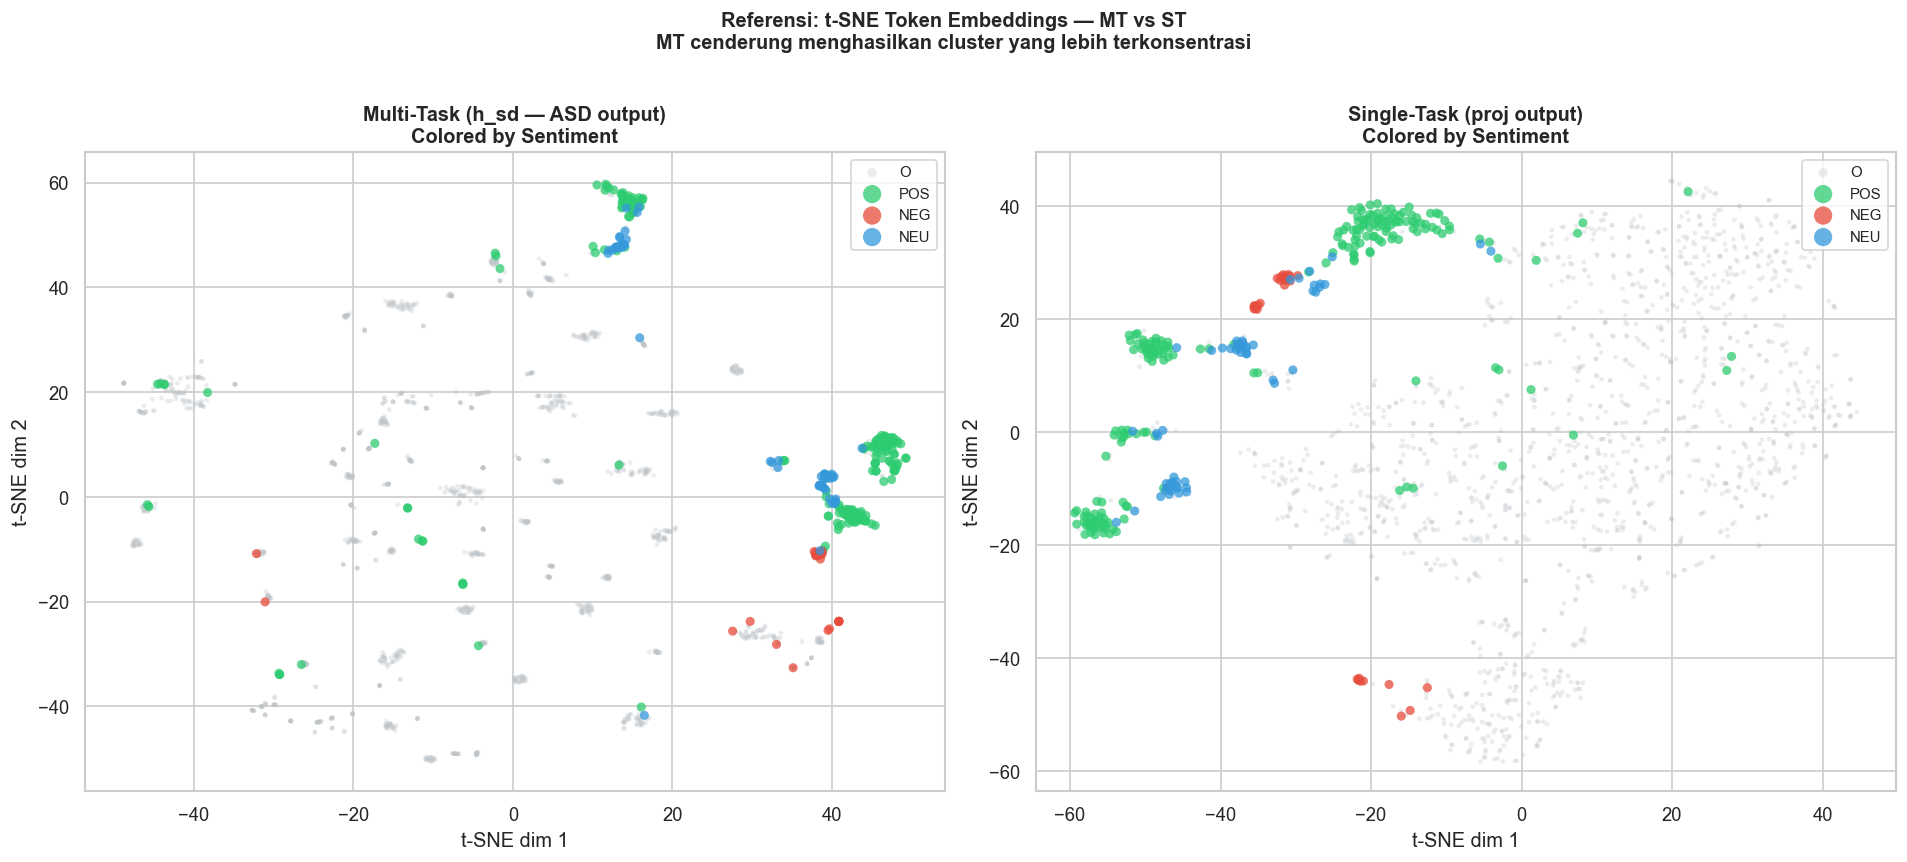

In [9]:
# Reference: t-SNE scatter colored by sentiment (same as NB15)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for label_type in ['O', 'POS', 'NEG', 'NEU']:
    for ax, tsne_2d, sents, title in [
        (axes[0], mt_asd_2d, mt_sentiment, 'Multi-Task (h_sd — ASD output)\nColored by Sentiment'),
        (axes[1], st_proj_2d, st_sentiment, 'Single-Task (proj output)\nColored by Sentiment'),
    ]:
        mask = np.array([s == label_type for s in sents])
        if mask.any():
            pts = tsne_2d[mask]
            alpha = 0.3 if label_type == 'O' else 0.75
            size  = 8   if label_type == 'O' else 30
            ax.scatter(pts[:, 0], pts[:, 1], c=sentiment_colors[label_type],
                       label=label_type, alpha=alpha, s=size, edgecolors='none')

for ax, title in zip(axes, ['Multi-Task (h_sd — ASD output)\nColored by Sentiment',
                              'Single-Task (proj output)\nColored by Sentiment']):
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9, markerscale=2)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')

plt.suptitle('Referensi: t-SNE Token Embeddings — MT vs ST\n'
             'MT cenderung menghasilkan cluster yang lebih terkonsentrasi',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Analisis 1: Token Paling Representatif per Cluster

Temukan centroid setiap cluster sentimen di ruang 256-dim, lalu identifikasi token yang paling dekat ke centroid tersebut.
Ini menjawab: **"token apa yang dianggap model sebagai contoh paling tipikal dari setiap kelas?"**

TOKEN PALING REPRESENTATIF PER CLUSTER (cosine distance, 256-dim)

--- MT (h_sd) ---
  POS (n=203):  tempat, akses, tempat, desa, berlibur, tempat, tempat, tempatnya, acara, desa
  NEG (n= 28):  masuk, kolam, kamar, kamar, airnya, jalan, tempatnya, pengunjung, makanannya, parkir
  NEU (n= 56):  tiket, kuda, sawah, kuda, tempat, desa, tempat, umbul, wisata, harga

--- ST (proj) ---
  POS (n=203):  acara, spot, warga, wisata, tempat, pengalaman, tempat, tempat, tempat, tempat
  NEG (n= 28):  malam, pengunjung, berfoto, toa, airnya, parkir, tempatnya, airnya, mobil, makanannya
  NEU (n= 56):  tiket, ekowisata, kuda, kuda, tongkonan, cafe, adat, rumah, wisata, lokasi


C:\Users\jason\AppData\Local\Temp\ipykernel_16624\1279302337.py:55: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
d:\miniconda3\envs\ta_nlp\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


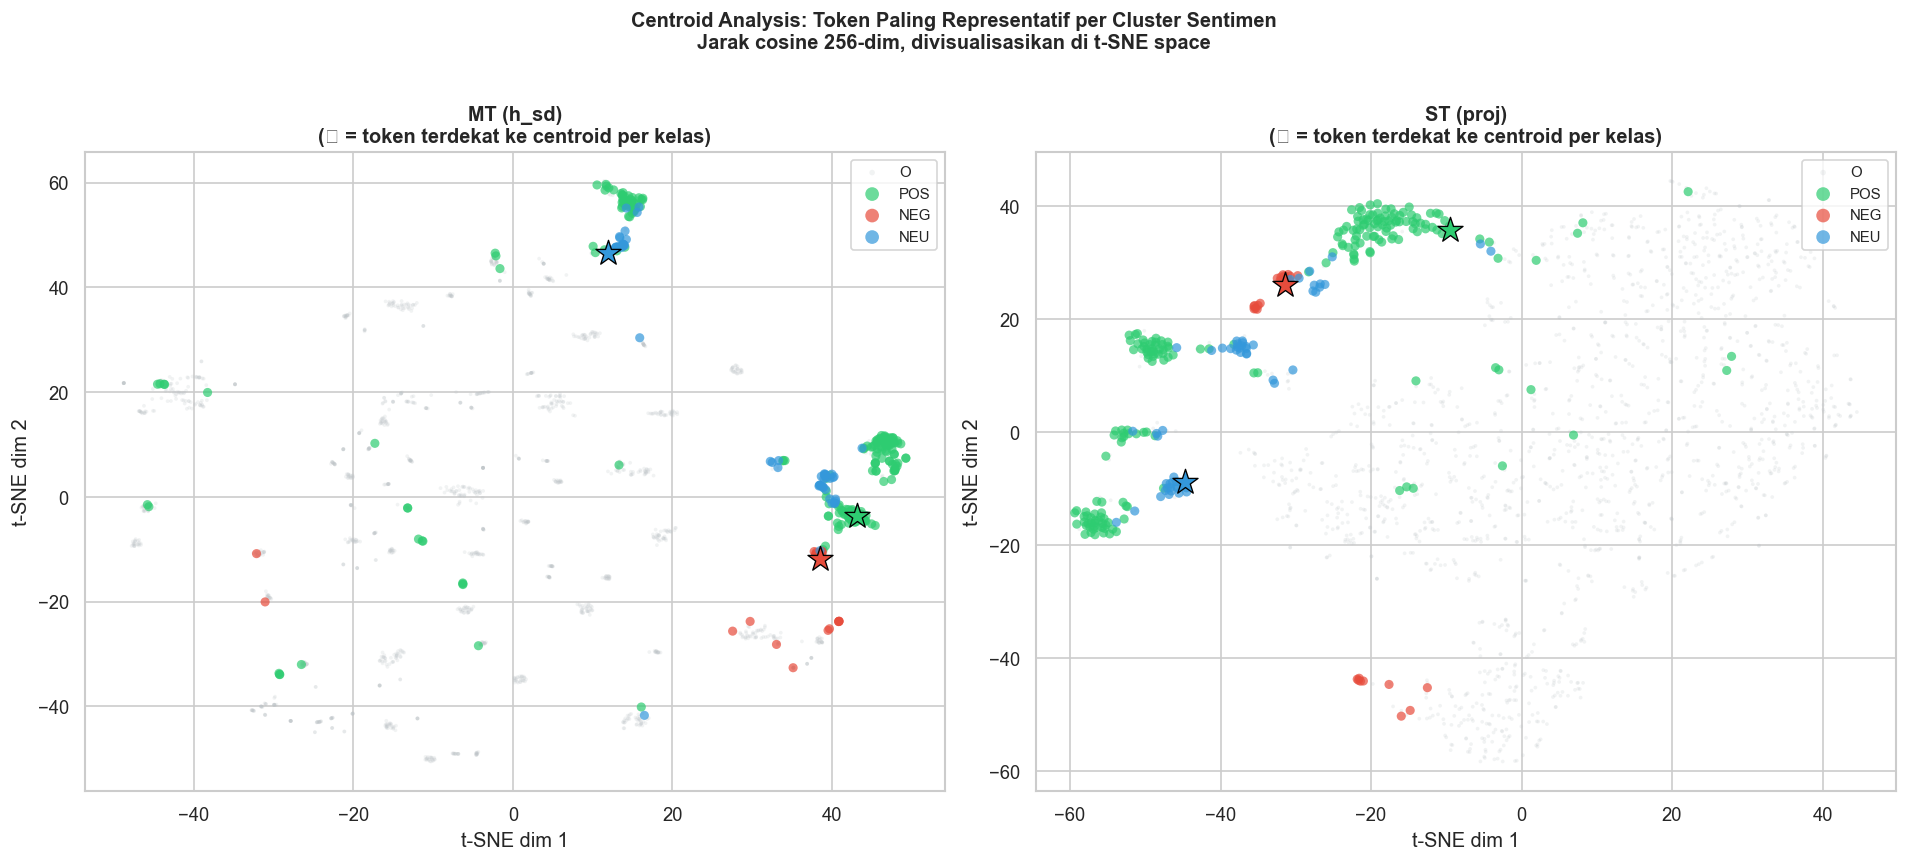

In [10]:
TOP_K = 10
SENTIMENT_CLASSES = ['POS', 'NEG', 'NEU']
cls_colors = {'POS': '#2ecc71', 'NEG': '#e74c3c', 'NEU': '#3498db'}

mt_asd_arr  = np.array(mt_asd_embeds)
st_proj_arr = np.array(st_proj_embeds)
mt_sents    = np.array(mt_sentiment)
st_sents    = np.array(st_sentiment)
mt_texts    = np.array(mt_token_texts)

print("=" * 70)
print("TOKEN PALING REPRESENTATIF PER CLUSTER (cosine distance, 256-dim)")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for model_name, embeds, sents, tsne_2d, ax in [
    ("MT (h_sd)", mt_asd_arr, mt_sents, mt_asd_2d, axes[0]),
    ("ST (proj)", st_proj_arr, st_sents, st_proj_2d, axes[1]),
]:
    print(f"\n--- {model_name} ---")
    o_mask = (sents == 'O')
    ax.scatter(tsne_2d[o_mask, 0], tsne_2d[o_mask, 1],
               c='#bdc3c7', s=5, alpha=0.2, label='O', edgecolors='none')

    for cls in SENTIMENT_CLASSES:
        cls_mask = (sents == cls)
        if cls_mask.sum() == 0:
            continue
        cls_embeds  = embeds[cls_mask]
        cls_texts   = mt_texts[cls_mask]   # same token order for both models
        cls_2d      = tsne_2d[cls_mask]

        centroid = cls_embeds.mean(axis=0, keepdims=True)
        dists    = cosine_distances(centroid, cls_embeds)[0]
        top_idx  = np.argsort(dists)[:TOP_K]
        top_toks = cls_texts[top_idx]

        ax.scatter(cls_2d[:, 0], cls_2d[:, 1],
                   c=cls_colors[cls], s=30, alpha=0.7, label=cls, edgecolors='none')
        nearest_pt = cls_2d[top_idx[0]]
        ax.scatter(nearest_pt[0], nearest_pt[1], c=cls_colors[cls], s=250,
                   marker='*', edgecolors='black', linewidths=0.8, zorder=5)

        token_str = ', '.join(top_toks)
        print(f"  {cls:3s} (n={cls_mask.sum():3d}):  {token_str}")

    ax.set_title(f'{model_name}\n(★ = token terdekat ke centroid per kelas)', fontweight='bold')
    ax.legend(fontsize=9, markerscale=1.5)
    ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')

plt.suptitle('Centroid Analysis: Token Paling Representatif per Cluster Sentimen\n'
             'Jarak cosine 256-dim, divisualisasikan di t-SNE space',
             fontweight='bold', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## Analisis 2: Seberapa Tight Cluster MT vs ST?

Ukur **mean cosine distance** dari setiap token ke centroid kelasnya di ruang 256-dim (bukan 2D t-SNE).
Nilai lebih rendah = token dalam cluster lebih homogen = cluster lebih tight.

Juga bandingkan silhouette score 256-dim dengan nilai 2D dari NB15 sebagai referensi.

INTRA-CLUSTER TIGHTNESS (mean cosine distance ke centroid, 256-dim)
Lebih rendah = representasi dalam cluster lebih homogen

MT (h_sd):
  POS (n= 203): mean dist = 0.1821
  NEG (n=  28): mean dist = 0.1465
  NEU (n=  56): mean dist = 0.2214
  O   (n=1539): mean dist = 0.0467
  Silhouette (non-O, 256-dim cosine): 0.2386

ST (proj):
  POS (n= 203): mean dist = 0.2207
  NEG (n=  28): mean dist = 0.1927
  NEU (n=  56): mean dist = 0.2339
  O   (n=1539): mean dist = 0.0252
  Silhouette (non-O, 256-dim cosine): 0.3532


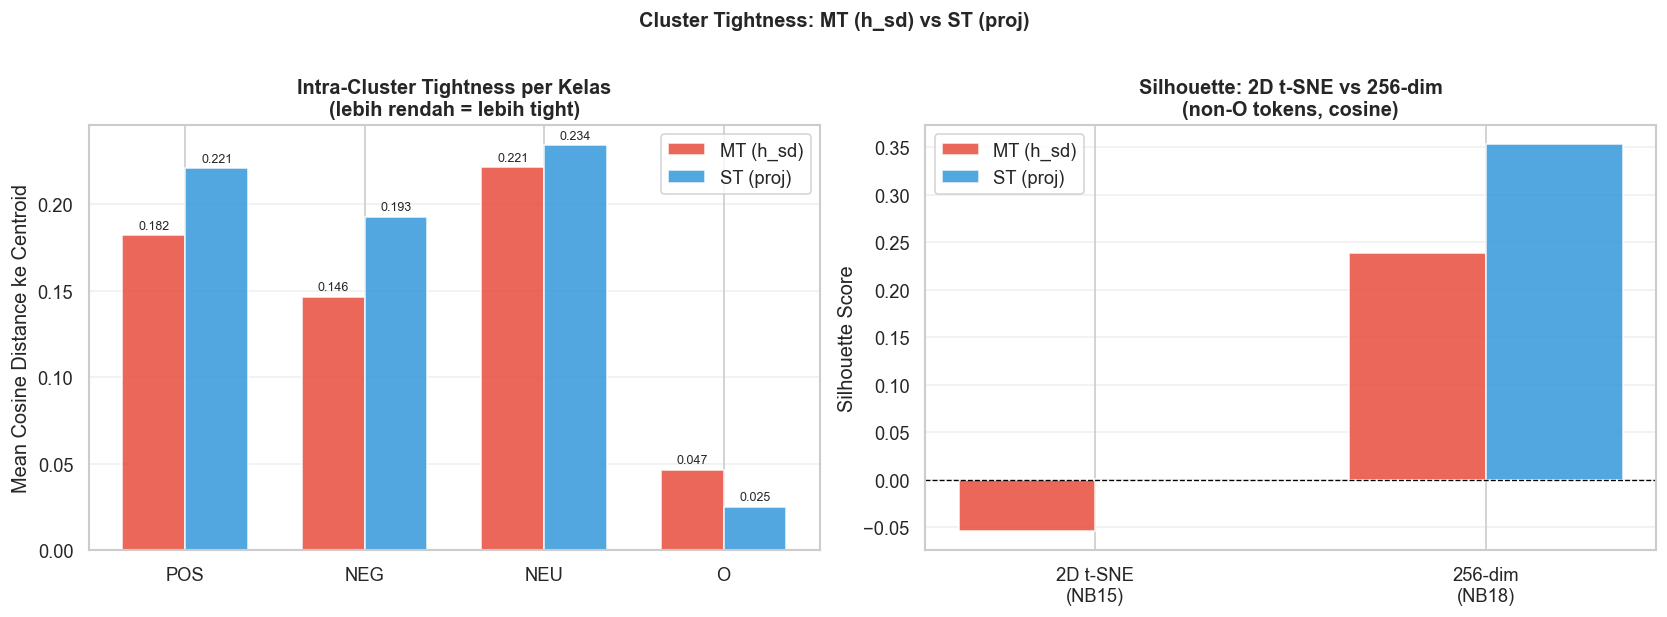

In [11]:
print("=" * 70)
print("INTRA-CLUSTER TIGHTNESS (mean cosine distance ke centroid, 256-dim)")
print("Lebih rendah = representasi dalam cluster lebih homogen")
print("=" * 70)

results_tight = {}
for model_name, embeds, sents in [
    ("MT (h_sd)", mt_asd_arr, mt_sents),
    ("ST (proj)", st_proj_arr, st_sents),
]:
    results_tight[model_name] = {}
    print(f"\n{model_name}:")
    for cls in ['POS', 'NEG', 'NEU', 'O']:
        mask = (sents == cls)
        if mask.sum() < 2:
            continue
        cls_e    = embeds[mask]
        centroid = cls_e.mean(axis=0, keepdims=True)
        dists    = cosine_distances(centroid, cls_e)[0]
        mean_d   = dists.mean()
        results_tight[model_name][cls] = mean_d
        print(f"  {cls:3s} (n={mask.sum():4d}): mean dist = {mean_d:.4f}")

    non_o = (sents != 'O')
    if non_o.sum() > 10:
        sil = silhouette_score(embeds[non_o], sents[non_o], metric='cosine',
                               sample_size=min(int(non_o.sum()), 500), random_state=SEED)
        results_tight[model_name]['silhouette_256d'] = sil
        print(f"  Silhouette (non-O, 256-dim cosine): {sil:.4f}")

# Grouped bar chart
classes_plot = ['POS', 'NEG', 'NEU', 'O']
x = np.arange(len(classes_plot))
width = 0.35
model_list = list(results_tight.keys())
bar_colors = {'MT (h_sd)': '#e74c3c', 'ST (proj)': '#3498db'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for i, mname in enumerate(model_list):
    vals = [results_tight[mname].get(cls, 0) for cls in classes_plot]
    bars = ax.bar(x + i * width, vals, width, label=mname,
                  color=bar_colors[mname], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(classes_plot)
ax.set_ylabel('Mean Cosine Distance ke Centroid')
ax.set_title('Intra-Cluster Tightness per Kelas\n(lebih rendah = lebih tight)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# Silhouette comparison: 2D (NB15 ref) vs 256-dim (NB18)
ax = axes[1]
sil_vals = {
    'MT (h_sd)': {'2D t-SNE\n(NB15)': -0.0542, '256-dim\n(NB18)': results_tight['MT (h_sd)'].get('silhouette_256d', 0)},
    'ST (proj)': {'2D t-SNE\n(NB15)':  0.0002, '256-dim\n(NB18)': results_tight['ST (proj)'].get('silhouette_256d', 0)},
}
x2 = np.arange(2)
for i, mname in enumerate(model_list):
    v = list(sil_vals[mname].values())
    ax.bar(x2 + i * width, v, width, label=mname, color=bar_colors[mname], alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x2 + width / 2)
ax.set_xticklabels(list(sil_vals['MT (h_sd)'].keys()))
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette: 2D t-SNE vs 256-dim\n(non-O tokens, cosine)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Cluster Tightness: MT (h_sd) vs ST (proj)', fontweight='bold', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## Analisis 3: Komposisi Leksikal Cluster MT

Kata-kata apa yang paling sering muncul di setiap cluster?
Tag `(+lex)` / `(-lex)` menunjukkan apakah kata tersebut ada di sentiment lexicon.
Ini menjawab: **apakah MT memang mengcluster kata-kata yang bermakna sentimen?**

KOMPOSISI LEKSIKAL CLUSTER MT (h_sd) PER KELAS SENTIMEN

[POS] n=203 tokens:
  tempat                  23x  (-lex)
  wisata                  15x  
  tempatnya               14x  
  desa                    10x  
  harga                    7x  (+lex)
  airnya                   6x  
  air                      5x  (-lex)
  suasana                  4x  (+lex)
  makanan                  4x  (+lex)
  foto                     4x  (+lex)
  pengalaman               3x  (+lex)
  tiket                    3x  

[NEG] n=28 tokens:
  parkir                   2x  (+lex)
  mobil                    2x  (+lex)
  airnya                   2x  
  kamar                    2x  
  mandi                    2x  
  masuk                    2x  (-lex)
  makanannya               1x  
  kebersihan               1x  
  kolam                    1x  (-lex)
  besar                    1x  
  jalan                    1x  
  berfoto                  1x  

[NEU] n=56 tokens:
  wisata                   7x  
  tempat         

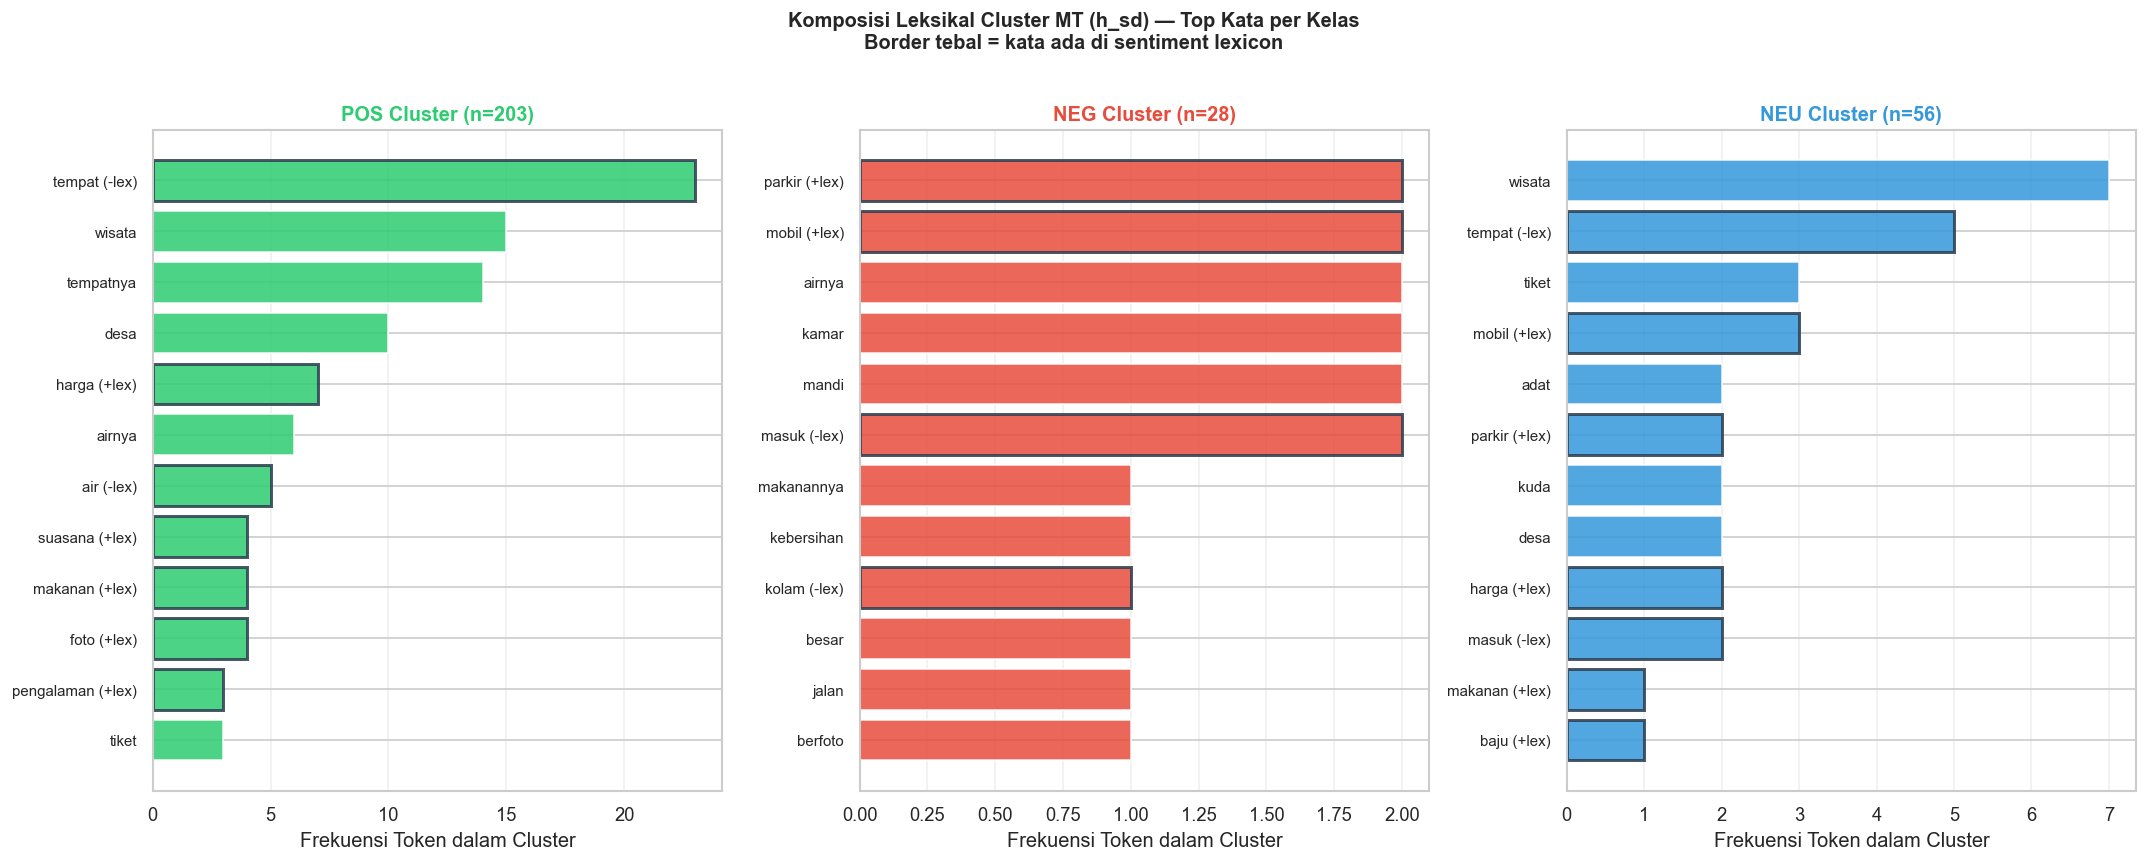

In [12]:
stopwords_id = {
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'ada', 'tidak',
    'dengan', 'untuk', 'pada', 'atau', 'juga', 'sudah', 'bisa', 'saya',
    'kami', 'kita', 'tapi', 'namun', 'kalau', 'karena', 'jika', 'sangat',
    'cukup', 'lebih', 'nya', 'lagi', 'aja', 'sih', 'kan', 'pun', 'lah',
    'ya', 'ga', 'gak', 'nggak', 'dg', 'yg', 'utk', 'dgn', 'tp', 'gd',
}
TOP_WORDS = 12

print("=" * 70)
print("KOMPOSISI LEKSIKAL CLUSTER MT (h_sd) PER KELAS SENTIMEN")
print("=" * 70)

cluster_info = {}
for cls in SENTIMENT_CLASSES:
    cls_tokens = [mt_token_texts[i].lower().strip(string.punctuation)
                  for i, s in enumerate(mt_sentiment) if s == cls]
    counts   = Counter(t for t in cls_tokens if len(t) > 1 and t not in stopwords_id)
    top_list = counts.most_common(TOP_WORDS)
    tagged   = [(w, f, '(+lex)' if w in pos_lexicon else '(-lex)' if w in neg_lexicon else '')
                for w, f in top_list]
    cluster_info[cls] = tagged

    n_cls = sum(1 for s in mt_sentiment if s == cls)
    print(f"\n[{cls}] n={n_cls} tokens:")
    for word, freq, tag in tagged:
        print(f"  {word:<22s} {freq:3d}x  {tag}")

print("\n--- Lexicon coverage per cluster ---")
for cls in SENTIMENT_CLASSES:
    toks   = [mt_token_texts[i].lower().strip(string.punctuation)
              for i, s in enumerate(mt_sentiment) if s == cls]
    n      = len(toks)
    in_pos = sum(1 for t in toks if t in pos_lexicon)
    in_neg = sum(1 for t in toks if t in neg_lexicon)
    print(f"  {cls}: {n} tokens | POS-lex: {in_pos} ({100*in_pos/n:.1f}%) | NEG-lex: {in_neg} ({100*in_neg/n:.1f}%)")

# Horizontal bar charts
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for idx, cls in enumerate(SENTIMENT_CLASSES):
    ax   = axes[idx]
    data = cluster_info[cls]
    labs = [f"{w} {t}" if t else w for w, f, t in data]
    vals = [f for w, f, t in data]
    tags = [t for w, f, t in data]

    bars = ax.barh(range(len(data)), vals, color=cls_colors[cls], alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(labs, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Frekuensi Token dalam Cluster')
    n_cls = sum(1 for s in mt_sentiment if s == cls)
    ax.set_title(f'{cls} Cluster (n={n_cls})', fontweight='bold', color=cls_colors[cls])
    ax.grid(True, alpha=0.3, axis='x')

    for bar_obj, tag in zip(bars, tags):
        if tag:
            bar_obj.set_edgecolor('#2c3e50')
            bar_obj.set_linewidth(1.8)

plt.suptitle('Komposisi Leksikal Cluster MT (h_sd) — Top Kata per Kelas\n'
             'Border tebal = kata ada di sentiment lexicon',
             fontweight='bold', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()